## Campo elétrico, potencial elétrico, linhas equipotenciais

Bibliotecas

In [7]:
import numpy as np
import math
import matplotlib.pyplot as plt 

Dados experimentais

In [8]:
Ve = [16.2, 14.3, 12.8, 10.3, 8.5, 7, 5.9, 4.6, 3.5, 2.6, 1.7, 0]

d = 0.5

xe = [d * i for i in range(len(Ve))]

Vi = [14.3, 12.8, 10.3, 8.5, 7, 5.9, 4.6, 3.5, 2.6, 1.7, 0]

xi = [d * i+0.5 for i in range(len(Vi))]

xi

[0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5]

Parâmetros ajustados: A = 6.0560, B = 11.9109
Equação ajustada: V = -6.0560*ln(x) + 11.9109
Erro padrão dos parâmetros: A = 0.4259, B = 0.4877
R² = 0.9574


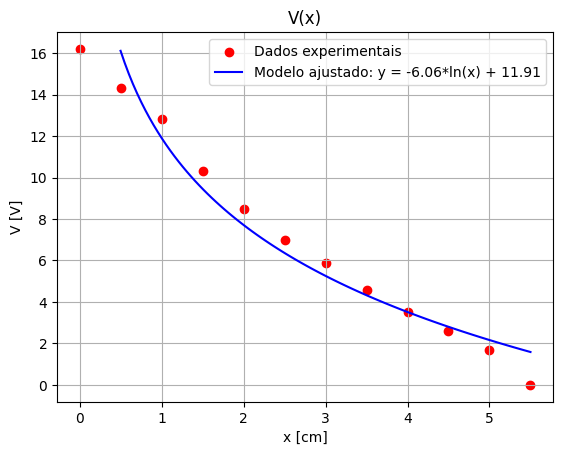

In [9]:
from scipy.optimize import curve_fit
from scipy.stats import linregress

def f(x, A, B):
    return -A * np.log(x) + B

if len(xi) != len(Vi):
    raise ValueError("xi e Vi devem ter o mesmo tamanho")

# Converter os dados para arrays do NumPy
x_data = np.array(xi)
y_data = np.array(Vi)

# Ajuste do modelo usando curve_fit
popt, pcov = curve_fit(f, x_data, y_data)

# Parâmetros ajustados
A, B = popt
print(f"Parâmetros ajustados: A = {A:.4f}, B = {B:.4f}")
print(f'Equação ajustada: V = -{A:.4f}*ln(x) + {B:.4f}')
# Calcular o erro padrão dos parâmetros
perr = np.sqrt(np.diag(pcov))
print(f"Erro padrão dos parâmetros: A = {perr[0]:.4f}, B = {perr[1]:.4f}")
# Calcular R**2
slope, intercept, r_value, p_value, std_err = linregress(f(x_data,*popt),y_data)
print(f"R² = {r_value**2:.4f}")

# Gerar valores ajustados para o gráfico
x_fit = np.linspace(min(xi), max(xi), 100)
y_fit = f(x_fit, A, B)

# Plotar os dados experimentais e o modelo ajustado
plt.scatter(xe, Ve, label="Dados experimentais", color="red")
plt.plot(x_fit, y_fit, label=f"Modelo ajustado: y = -{A:.2f}*ln(x) + {B:.2f}", color="blue")
plt.xlabel('x [cm]')
plt.ylabel('V [V]')
plt.title('V(x)')
plt.legend()
plt.grid()
plt.show()

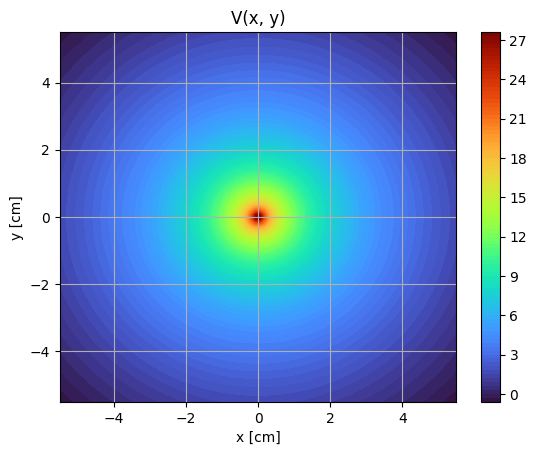

In [10]:
# Superfície 2d do caimento do potencial

# Grade x, y

x = np.linspace(-xi[-1], xi[-1], 100)
y = np.linspace(-xi[-1], xi[-1], 100)

X, Y = np.meshgrid(x, y)

# Superfície
z = -A*np.log(np.sqrt(X**2 + Y**2)) + B
Z = z.reshape(X.shape)

plt.contourf(X, Y, Z, 100, cmap='turbo')
plt.colorbar()
plt.xlabel('x [cm]')
plt.ylabel('y [cm]')
plt.grid()
plt.title('V(x, y)')
plt.show()

1.464596926445298
9.6
1.6801360489130464
8.768541972818912
Diferença entre os raios: -0.22 cm


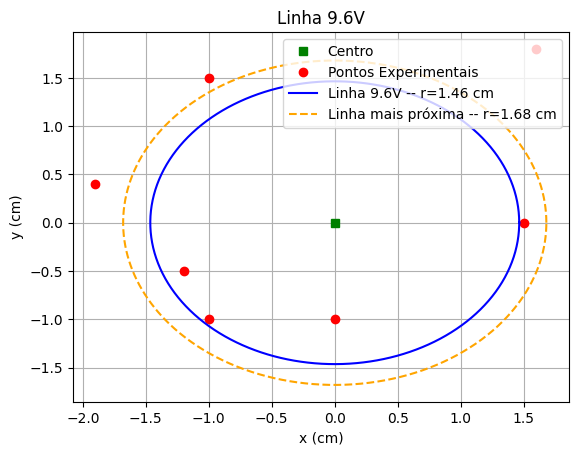

In [11]:
# Linha 9.6

xi = [0, 1.5, -1, -1.2, -1.9, -1, 1.6]
yi = [-1, 0, -1, -0.5, 0.4, 1.5, 1.8]
x0 = 0
y0 = 0

# Circulo 9.6V
l1 = np.exp((B - 9.6) / A)
print(l1)
print(f(l1, A, B))


theta = np.linspace(0, 2*np.pi, 1000)
x = l1*np.cos(theta)
y = l1*np.sin(theta)

# Circulo que melhor se ajusta aos pontos experimentais
xi = np.array(xi)
yi = np.array(yi)
l2 = np.sqrt(np.mean((xi - x0)**2 + (yi - y0)**2))
print(l2)
print(f(l2, A, B))

print(f'Diferença entre os raios: {l1-l2:.2f} cm')

x2 = l2*np.cos(theta)
y2 = l2*np.sin(theta)

plt.plot(x0, y0, 'gs', label='Centro')
plt.plot(xi, yi, 'ro', label='Pontos Experimentais')
plt.plot(x, y, 'b', label=f'Linha 9.6V -- r={l1:.2f} cm')
plt.plot(x2, y2, 'orange', linestyle='--', label=f'Linha mais próxima -- r={l2:.2f} cm')
plt.legend(loc='upper right')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.title('Linha 9.6V')
plt.grid()

2.743010291891485
5.8
3.3726843908080104
4.54850735092424
Diferença entre os raios: -0.63 cm


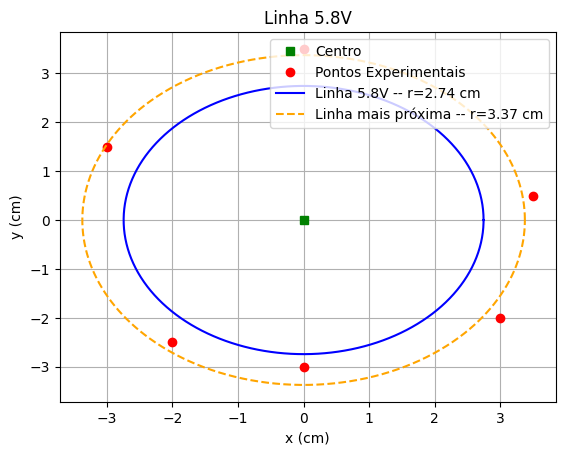

In [12]:
# Linha 5.8V
xi = [0, -2, -3, 0, 3.5, 3]
yi = [-3, -2.5,  1.5,  3.5,  0.5, -2]

# Circulo 5.8V
l1 = np.exp((B - 5.8) / A)
print(l1)
print(f(l1, A, B))

theta = np.linspace(0, 2*np.pi, 1000)
x = l1 * np.cos(theta)
y = l1 * np.sin(theta)

# Circulo que melhor se ajusta aos pontos experimentais
xi = np.array(xi)
yi = np.array(yi)
l2 = np.sqrt(np.mean((xi - x0)**2 + (yi - y0)**2))
print(l2)
print(f(l2, A, B))

print(f'Diferença entre os raios: {l1-l2:.2f} cm')

x2 = l2 * np.cos(theta)
y2 = l2 * np.sin(theta)

plt.plot(x0, y0, 'gs', label='Centro')
plt.plot(xi, yi, 'ro', label='Pontos Experimentais')
plt.plot(x, y, 'b', label=f'Linha 5.8V -- r={l1:.2f} cm')
plt.plot(x2, y2, 'orange', linestyle='--', label=f'Linha mais próxima -- r={l2:.2f} cm')
plt.legend(loc='upper right')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.title('Linha 5.8V')
plt.grid()
